Лаба 4. Интервальные оценки

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import scipy.stats as stats

1 задание

In [2]:
# Нормальное распределение N(0,1)
# a: P(X ∈ [-a, a]) = 0.8
# Для симметричного интервала: P(X < a) = (0.8 + 1)/2 = 0.9
a = 0.8
p_norm_a = (a + 1) / 2  # = 0.9
a_norm = stats.norm.ppf(p_norm_a)  # ppf = percent point function (обратная функция распределения)
print(f"a) P(X ∈ [-a, a]) = {a}")
print(f"   → P(X < a) = {p_norm_a}")
print(f"   → a = Φ⁻¹({p_norm_a}) = {a_norm:.4f}")
print(f"   Проверка: P(X ∈ [-{a_norm:.4f}, {a_norm:.4f}]) = {stats.norm.cdf(a_norm) - stats.norm.cdf(-a_norm):.4f}")

# b: P(X > b) = 0.4
# P(X > b) = 1 - Φ(b) = 0.4 → Φ(b) = 0.6
b = 0.4
p_norm_b = 1 - b  # = 0.6
b_norm = stats.norm.ppf(p_norm_b)
print(f"\nb) P(X > b) = {b}")
print(f"   → P(X < b) = {p_norm_b}")
print(f"   → b = Φ⁻¹({p_norm_b}) = {b_norm:.4f}")
print(f"   Проверка: P(X > {b_norm:.4f}) = {1 - stats.norm.cdf(b_norm):.4f}")

# c: P(X < -c) + P(X > c) = 0.3
# Из-за симметрии: P(X < -c) = P(X > c), значит 2·P(X > c) = 0.3 → P(X > c) = 0.15
# P(X < c) = 1 - 0.15 = 0.85
c = 0.3
p_tail = c / 2  # = 0.15
p_norm_c = 1 - p_tail  # = 0.85
c_norm = stats.norm.ppf(p_norm_c)
print(f"\nc) P(X < -c) + P(X > c) = {c}")
print(f"   Из-за симметрии: 2·P(X > c) = {c} → P(X > c) = {p_tail}")
print(f"   → P(X < c) = {p_norm_c}")
print(f"   → c = Φ⁻¹({p_norm_c}) = {c_norm:.4f}")
print(f"   Проверка: P(X < -{c_norm:.4f}) + P(X > {c_norm:.4f}) = {2 * (1 - stats.norm.cdf(c_norm)):.4f}")


# Распределение Стьюдента T(5)
df_t = 5  # степени свободы

# a: P(X ∈ [-a, a]) = 0.8 (аналогично нормальному)
a_t = stats.t.ppf(p_norm_a, df_t)  # p_norm_a = 0.9
print(f"a) P(X ∈ [-a, a]) = {a}")
print(f"   → a = T⁻¹({p_norm_a}, ν={df_t}) = {a_t:.4f}")
print(f"   Сравнение с нормальным: a_норм = {a_norm:.4f}, a_тью = {a_t:.4f} (больше, т.к. хвосты тяжелее)")
print(f"   Проверка: P ∈ [{-a_t:.4f}, {a_t:.4f}] = {stats.t.cdf(a_t, df_t) - stats.t.cdf(-a_t, df_t):.4f}")

# b: P(X > b) = 0.4
b_t = stats.t.ppf(p_norm_b, df_t)  # p_norm_b = 0.6
print(f"\nb) P(X > b) = {b}")
print(f"   → b = T⁻¹({p_norm_b}, ν={df_t}) = {b_t:.4f}")
print(f"   Сравнение: b_норм = {b_norm:.4f}, b_тью = {b_t:.4f}")
print(f"   Проверка: P(X > {b_t:.4f}) = {1 - stats.t.cdf(b_t, df_t):.4f}")

# c: P(X < -c) + P(X > c) = 0.3
c_t = stats.t.ppf(p_norm_c, df_t)  # p_norm_c = 0.85
print(f"\nc) P(X < -c) + P(X > c) = {c}")
print(f"   → c = T⁻¹({p_norm_c}, ν={df_t}) = {c_t:.4f}")
print(f"   Сравнение: c_норм = {c_norm:.4f}, c_тью = {c_t:.4f}")
print(f"   Проверка: сумма хвостов = {2 * (1 - stats.t.cdf(c_t, df_t)):.4f}")

a) P(X ∈ [-a, a]) = 0.8
   → P(X < a) = 0.9
   → a = Φ⁻¹(0.9) = 1.2816
   Проверка: P(X ∈ [-1.2816, 1.2816]) = 0.8000

b) P(X > b) = 0.4
   → P(X < b) = 0.6
   → b = Φ⁻¹(0.6) = 0.2533
   Проверка: P(X > 0.2533) = 0.4000

c) P(X < -c) + P(X > c) = 0.3
   Из-за симметрии: 2·P(X > c) = 0.3 → P(X > c) = 0.15
   → P(X < c) = 0.85
   → c = Φ⁻¹(0.85) = 1.0364
   Проверка: P(X < -1.0364) + P(X > 1.0364) = 0.3000
a) P(X ∈ [-a, a]) = 0.8
   → a = T⁻¹(0.9, ν=5) = 1.4759
   Сравнение с нормальным: a_норм = 1.2816, a_тью = 1.4759 (больше, т.к. хвосты тяжелее)
   Проверка: P ∈ [-1.4759, 1.4759] = 0.8000

b) P(X > b) = 0.4
   → b = T⁻¹(0.6, ν=5) = 0.2672
   Сравнение: b_норм = 0.2533, b_тью = 0.2672
   Проверка: P(X > 0.2672) = 0.4000

c) P(X < -c) + P(X > c) = 0.3
   → c = T⁻¹(0.85, ν=5) = 1.1558
   Сравнение: c_норм = 1.0364, c_тью = 1.1558
   Проверка: сумма хвостов = 0.3000


In [3]:
# Нахождение вероятностей γ по заданным границам
# γ1: P(X ∈ [-0.1, 0.1])
gamma1_norm = stats.norm.cdf(0.1) - stats.norm.cdf(-0.1)
print(f"\nγ1: P(X ∈ [-0.1, 0.1]) = Φ(0.1) - Φ(-0.1) = {gamma1_norm:.6f}")
print(f"   Поскольку Φ(-0.1) = 1 - Φ(0.1), то = 2Φ(0.1) - 1 = {2 * stats.norm.cdf(0.1) - 1:.6f}")

# γ2: P(X > 0.7)
gamma2_norm = 1 - stats.norm.cdf(0.7)
print(f"\nγ2: P(X > 0.7) = 1 - Φ(0.7) = {gamma2_norm:.6f}")

# γ3: P(X < -0.4) + P(X > 0.4)
# Из-за симметрии: = 2·P(X > 0.4)
gamma3_norm = 2 * (1 - stats.norm.cdf(0.4))
print(f"\nγ3: P(X < -0.4) + P(X > 0.4) = 2·P(X > 0.4) = {gamma3_norm:.6f}")
print(f"   Проверка: P(X < -0.4) = {stats.norm.cdf(-0.4):.6f}, P(X > 0.4) = {1 - stats.norm.cdf(0.4):.6f}")

# Распределение Стьюдента T(5) - вероятности
# γ1: P(X ∈ [-0.1, 0.1])
gamma1_t = stats.t.cdf(0.1, df_t) - stats.t.cdf(-0.1, df_t)
print(f"\nγ1: P(X ∈ [-0.1, 0.1]) = {gamma1_t:.6f}")
print(f"   Сравнение: γ1_норм = {gamma1_norm:.6f}, γ1_тью = {gamma1_t:.6f}")

# γ2: P(X > 0.7)
gamma2_t = 1 - stats.t.cdf(0.7, df_t)
print(f"\nγ2: P(X > 0.7) = {gamma2_t:.6f}")
print(f"   Сравнение: γ2_норм = {gamma2_norm:.6f}, γ2_тью = {gamma2_t:.6f}")
print(f"   У тью вероятность больше, т.к. хвосты тяжелее")

# γ3: P(X < -0.4) + P(X > 0.4)
gamma3_t = 2 * (1 - stats.t.cdf(0.4, df_t))
print(f"\nγ3: P(X < -0.4) + P(X > 0.4) = {gamma3_t:.6f}")
print(f"   Сравнение: γ3_норм = {gamma3_norm:.6f}, γ3_тью = {gamma3_t:.6f}")


γ1: P(X ∈ [-0.1, 0.1]) = Φ(0.1) - Φ(-0.1) = 0.079656
   Поскольку Φ(-0.1) = 1 - Φ(0.1), то = 2Φ(0.1) - 1 = 0.079656

γ2: P(X > 0.7) = 1 - Φ(0.7) = 0.241964

γ3: P(X < -0.4) + P(X > 0.4) = 2·P(X > 0.4) = 0.689157
   Проверка: P(X < -0.4) = 0.344578, P(X > 0.4) = 0.344578

γ1: P(X ∈ [-0.1, 0.1]) = 0.075770
   Сравнение: γ1_норм = 0.079656, γ1_тью = 0.075770

γ2: P(X > 0.7) = 0.257574
   Сравнение: γ2_норм = 0.241964, γ2_тью = 0.257574
   У тью вероятность больше, т.к. хвосты тяжелее

γ3: P(X < -0.4) + P(X > 0.4) = 0.705673
   Сравнение: γ3_норм = 0.689157, γ3_тью = 0.705673


In [4]:
# 2.3 Распределение хи-квадрат χ²(10)
print("    Неотрицательная случайная величина, скошена вправо")
print(f"   M[X] = ν = {10}, D[X] = 2ν = {20}")
print()

df_chi2 = 10

# a: P(X > a) = 0.4
# a - верхний квантиль (0.6 снизу)
prob_chi2_a = 0.4
p_chi2_a = 1 - prob_chi2_a  # = 0.6
a_chi2 = stats.chi2.ppf(p_chi2_a, df_chi2)
print(f"a) P(X > a) = {prob_chi2_a}")
print(f"   → P(X < a) = {p_chi2_a}")
print(f"   → a = χ²⁻¹({p_chi2_a}, ν={df_chi2}) = {a_chi2:.4f}")
print(f"   Проверка: P(X > {a_chi2:.4f}) = {1 - stats.chi2.cdf(a_chi2, df_chi2):.4f}")

# b: P(X < b) = 0.4
# b - нижний квантиль (40-й процентиль)
prob_chi2_b = 0.4
b_chi2 = stats.chi2.ppf(prob_chi2_b, df_chi2)
print(f"\nb) P(X < b) = {prob_chi2_b}")
print(f"   → b = χ²⁻¹({prob_chi2_b}, ν={df_chi2}) = {b_chi2:.4f}")
print(f"   Проверка: P(X < {b_chi2:.4f}) = {stats.chi2.cdf(b_chi2, df_chi2):.4f}")

# γ: P(X > 12)
gamma_chi2 = 1 - stats.chi2.cdf(12, df_chi2)
print(f"\nγ: P(X > 12) = 1 - F_χ²(12) = {gamma_chi2:.6f}")
print(f"   Проверка: {gamma_chi2:.6f}")

    Неотрицательная случайная величина, скошена вправо
   M[X] = ν = 10, D[X] = 2ν = 20

a) P(X > a) = 0.4
   → P(X < a) = 0.6
   → a = χ²⁻¹(0.6, ν=10) = 10.4732
   Проверка: P(X > 10.4732) = 0.4000

b) P(X < b) = 0.4
   → b = χ²⁻¹(0.4, ν=10) = 8.2955
   Проверка: P(X < 8.2955) = 0.4000

γ: P(X > 12) = 1 - F_χ²(12) = 0.285057
   Проверка: 0.285057


In [5]:
data = pd.DataFrame(
    [
        [a_norm, a_t, "γ1", gamma1_norm, gamma1_t, "a", a_chi2],
        [b_norm, b_t, "γ2", gamma2_norm, gamma2_t, "b", b_chi2],
        [c_norm, c_t, "γ3", gamma3_norm, gamma3_t, "γ", gamma_chi2],
    ],
    columns=[
        "N(x, 0,1)", "T(x, 5)",
        "", 
        "N(x, 0,1)", "T(x, 5)",
        "", 
        "χ²(x, 10)"
    ],
    index=["a", "b", "c"]
)

data

,"N(x, 0,1)","T(x, 5)",,"N(x, 0,1)","T(x, 5)",,"χ²(x, 10)"
a,1.281552,1.475884,γ1,0.079656,0.075770,a,10.473236
b,0.253347,0.267181,γ2,0.241964,0.257574,b,8.295472
c,1.036433,1.155767,γ3,0.689157,0.705673,γ,0.285057


2.В scipy.stats сделайте реализацию выборки объемом N элементов из генеральной совокупности, распределенной по нормальному закону распределения (см. табл.1). Табл.1 Номер варианта = (остаток от деления номера в списке на 14) + (например, 5 студент в списке группы делает 6 вариант, а 25-й ─ 12 вариант)

In [6]:
my_var = (61 % 14) + 1
print(f"Мой вариант {my_var}")

data = pd.DataFrame({
    "var": list(range(1, 15)),
    "sigma":[0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 1, 0.1, 0.2, 0.3, 0.4],
    "m": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1, 2, 3, 4],
    "y, %": [87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 86]
})

par = data[data["var"] == my_var].iloc[0]
mu = par["m"]
sigma = par["sigma"]

N = 60
sample = stats.norm.rvs(loc = mu, scale = sigma, size = N, random_state = 42)

print(f"Используемые параметры: m={mu}, sigma={sigma}")
print(f"Среднее выборки: {sample.mean():.4f}")
print(f"Первые 5 элементов: {sample[:5]}")

Мой вариант 6
Используемые параметры: m=6.0, sigma=0.4
Среднее выборки: 5.9381
Первые 5 элементов: [6.19868566 5.94469428 6.25907542 6.60921194 5.90633865]


3.С помощью scipy.stats определите доверительные интервалы:

a) для математического ожидания генеральной совокупности в предположении, что среднеквадратичное отклонение известно (см. табл.1).

b) для математического ожидания генеральной совокупности в предположении, что среднеквадратичное отклонение НЕизвестно.

c) для дисперсии генеральной совокупности в предположением, что математическое ожидание НЕизвестно.

Для проверки полученных в этом пункте результатов вычислите аналогичные интервалы вручную (т.е. используя формулы, выведенные на лекции).

In [12]:
sigma = 0.4
mu = 6
N  = 60
gamma = 0.92

sample_mean = np.mean(sample)

# a)sigma известна
crit = stats.norm.ppf((gamma+1)/2)
S = (sample_mean - crit * (sigma / np.sqrt(N)), sample_mean + crit * (sigma / np.sqrt(N)))
print(f"а)sigma известна: {S}")

# b)sigma НЕизвестна
std_s = np.std(sample, ddof=1) # выборочное s стандартное отклонение

crit1 = stats.t.ppf((gamma+1)/2, df = N-1)
S1 = (sample_mean - crit1 * (std_s / np.sqrt(N)), sample_mean + crit1 * (std_s / np.sqrt(N)))
print(f"b)sigma НЕизвестна: {S1}")

# c)mu НЕизвестна
var_s = np.var(sample, ddof=1) # выборочная дисперсия (s^2)

chi12 = stats.chi2.ppf((1-gamma)/2, df = N-1)
chi22 = stats.chi2.ppf((1+gamma)/2, df = N-1)
S2 = ((N - 1)* var_s / chi22, (N - 1)* var_s / chi12)
print(f"c)mu НЕизвестна: {S2}")

а)sigma известна: (np.float64(5.847733086793178), np.float64(6.02854316675043))
b)sigma НЕизвестна: (np.float64(5.854563882754317), np.float64(6.021712370789291))
c)mu НЕизвестна: (np.float64(0.0982323840141792), np.float64(0.1880885157996946))


In [8]:
crit = stats.norm.ppf((gamma+1)/2)
epsilon = crit * (sigma / np.sqrt(N))
epsilon1 = epsilon / 2

N1 = ((crit * sigma) / epsilon1)**2
print(f"Необходимый объем выборки N1: {int(np.ceil(N1))}")

print(f"Отношение N1/N: {N1/N:.1f}")

Необходимый объем выборки N1: 241
Отношение N1/N: 4.0


5.1.Из всей таблицы взять данные для 10 стран с максимально разбросом температур в месяц вашего рождения.

In [9]:
df = pd.read_csv("daily_weather_data.csv")

birth_month=9
df['date'] = pd.to_datetime(df['date'], format = '%d-%m-%Y')
month=df[df['date'].dt.month==birth_month]
print(f"\nВсего записей в месяце {birth_month}: {len(month)}")

tmin_1 = month.groupby('country')['tmin'].min()
tmax_1 = month.groupby('country')['tmax'].max()
# Объединяем
country_1 = pd.merge(tmin_1, tmax_1, on='country')
country_1['temp_razbros'] = country_1['tmax'] - country_1['tmin'] #разброс
top10_country= country_1.sort_values(by='temp_razbros', ascending=False).head(10) #сортируем разброс по убыванию и берем топ 10
print(top10_country)


Всего записей в месяце 9: 28199
                 tmin  tmax  temp_razbros
country                                  
Kazakhstan       -2.4  37.6          40.0
Sweden          -12.3  25.2          37.5
Moldova          -0.7  35.3          36.0
Myanmar (Burma)   3.1  39.1          36.0
Egypt             3.0  38.2          35.2
Paraguay          7.2  42.4          35.2
Romania           1.9  36.9          35.0
Ukraine           0.6  35.4          34.8
Luxembourg        0.2  34.5          34.3
Italy             0.7  34.9          34.2


5.2.Для каждой из стран определить доверительные интервалы для математического ожидания и дисперсии случайной величины «tavg».

In [12]:
list_top10 = top10_country.index.tolist()
print(list_top10)
results = []
gamma = 0.95

for country in list_top10:
    tavg = month[month['country'] == country]['tavg']
    N = len(tavg)
    
    #Доверительный интервал для мат. ожидания
    #Используем t-распределение (так как сигма генеральной совокупности неизвестна)
    x_mean = np.mean(tavg) #мат ожидание
    s = np.std(tavg, ddof=1)
    raspred_t = stats.t(df=N-1)
    
    epsilon = (s / math.sqrt(N)) * raspred_t.ppf((1 + gamma) / 2)
    i_min_1 = x_mean - epsilon
    i_max_1 = x_mean + epsilon

    #Доверительный интервал для дисперсии
    s2 = np.var(tavg, ddof=1) #несмещенная дисперсия
    raspred_chi2 = stats.chi2(df=N-1)
    
    z1 = raspred_chi2.ppf((1 - gamma) / 2)
    z2 = raspred_chi2.ppf((1 + gamma) / 2)
    
    epsilon1 = ((N - 1) * s2) / z2
    epsilon2 = ((N - 1) * s2) / z1

    results.append({
        'country': country,
        'M': x_mean,
        'epsilon': epsilon,
        'D': s2
    })

    print(f"\nСтрана: {country}")
    print(f"  Мат ожидание: {x_mean:.4f}")
    print(f"  Доверительный интервал для мат. ожидания: [{i_min_1:.4f}, {i_max_1:.4f}]")
    print(f"  Несмещенная дисперсия: {s2:.4f}")
    print(f"  Доверительный интервал для дисперсии: [{epsilon1:.4f}, {epsilon2:.4f}]")
res_df = pd.DataFrame(results)
res_df

['Kazakhstan', 'Sweden', 'Moldova', 'Myanmar (Burma)', 'Egypt', 'Paraguay', 'Romania', 'Ukraine', 'Luxembourg', 'Italy']

Страна: Kazakhstan
  Мат ожидание: 13.6927
  Доверительный интервал для мат. ожидания: [12.8123, 14.5730]
  Несмещенная дисперсия: 29.7752
  Доверительный интервал для дисперсии: [24.0217, 37.8871]

Страна: Sweden
  Мат ожидание: 12.2300
  Доверительный интервал для мат. ожидания: [11.7854, 12.6746]
  Несмещенная дисперсия: 7.5927
  Доверительный интервал для дисперсии: [6.1256, 9.6613]

Страна: Moldova
  Мат ожидание: 17.7360
  Доверительный интервал для мат. ожидания: [17.0861, 18.3859]
  Несмещенная дисперсия: 16.2233
  Доверительный интервал для дисперсии: [13.0884, 20.6431]

Страна: Myanmar (Burma)
  Мат ожидание: 26.8217
  Доверительный интервал для мат. ожидания: [26.6189, 27.0245]
  Несмещенная дисперсия: 0.6163
  Доверительный интервал для дисперсии: [0.4428, 0.9168]

Страна: Egypt
  Мат ожидание: 28.4427
  Доверительный интервал для мат. ожидания: [28.2257

,country,M,epsilon,D
0,Kazakhstan,13.692667,0.880383,29.775181
1,Sweden,12.230000,0.444573,7.592718
2,Moldova,17.736000,0.649850,16.223259
3,Myanmar (Burma),26.821667,0.202800,0.616302
4,Egypt,28.442667,0.217004,1.809040
5,Paraguay,22.805333,0.769179,22.728294
6,Romania,19.542667,0.551232,11.672932
7,Ukraine,15.483333,0.683853,17.965425
8,Luxembourg,15.535333,0.515397,10.204582
9,Italy,22.281333,0.388746,5.805555


5.3.Отобразить средние и их доверительные интервалы на графике (для всех стран на одном графике). Страны на графике отображать в порядке уменьшения дисперсии. 

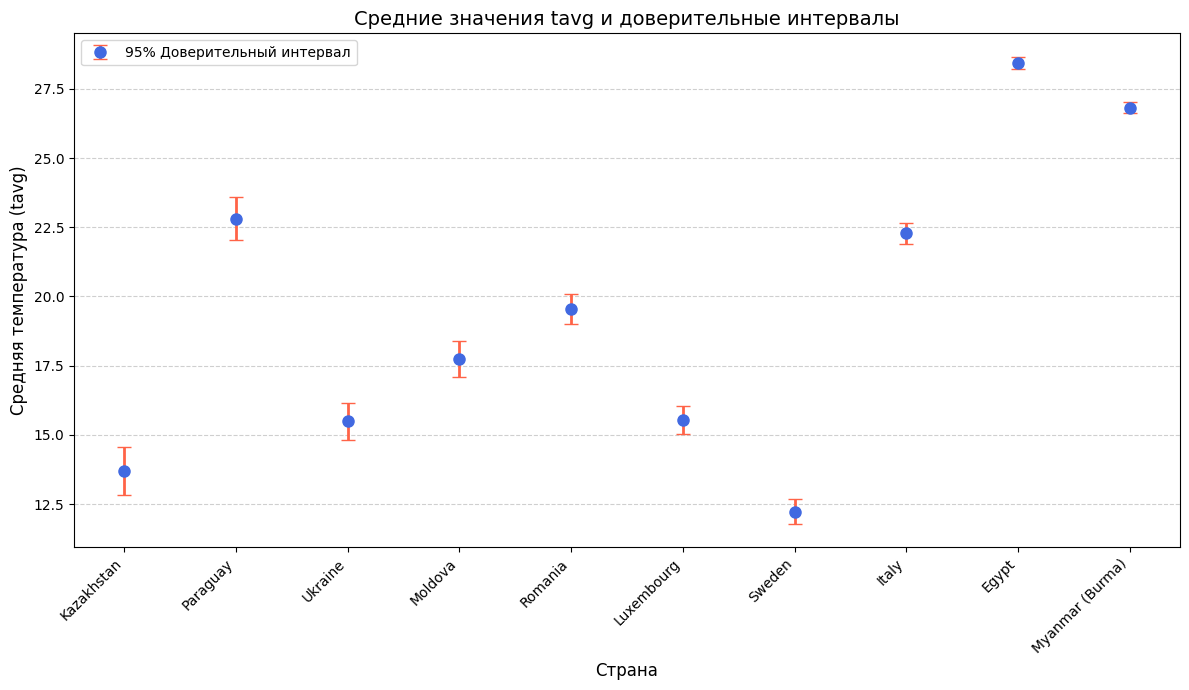

In [ ]:
res_df_sorted = res_df.sort_values(by='D', ascending=False)

plt.figure(figsize=(12, 7))

# Используем plt.errorbar для отображения средних (M) и доверительных интервалов (epsilon)
plt.errorbar(
    x=res_df_sorted['country'], 
    y=res_df_sorted['M'], 
    yerr=res_df_sorted['epsilon'], 
    fmt='o',           # 'o' означает точки для средних
    color='royalblue', # Цвет точек
    ecolor='tomato',   # Цвет "усов" (интервалов)
    capsize=5,         # Засечки на концах интервалов
    markersize=8,      # Размер точки
    linewidth=2,       # Толщина линий
    label='95% Доверительный интервал'
)

plt.title(f'Средние значения tavg и доверительные интервалы', fontsize=14)
plt.xlabel('Страна', fontsize=12) 
plt.ylabel('Средняя температура (tavg)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Поворот названий стран
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()